# Supervised Classification with a Born-Machine TTN

Same synthetic drift dataset and Born-rule inference as `classification.ipynb`,
but the joint model is a **binary tree tensor network** (`BinaryTTN`) instead of
an MPS chain.

The joint TTN models `p(ξ, y)` with the class label `y ∈ {1, …, C}` on the
last physical leaf (`M_path + 1` sites total; for `M_path = 15` this is a
perfect 16-leaf tree).

### What we compare
- TTN Born classifier (`class_probabilities_ttn`)
- Logistic regression baseline (same as MPS notebook)

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf
using Plots

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Synthetic Dataset

Two classes: cumulative sums of ±1 random walks with different drift.
- Class 1: positive drift → path tends to rise.
- Class 2: negative drift → path tends to fall.

In [2]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    labels = Vector{Int}(undef, N)
    for i in 1:N
        y = rand(rng, 1:2)
        d = y == 1 ? drift : -drift
        s = cumsum(d .+ σ .* randn(rng, M))
        paths[i,  :] = s
        labels[i]    = y
    end
    return paths, labels
end

rng = MersenneTwister(42)
N_train, N_test, M = 2_000, 500, 15

train_paths, train_labels = synthetic_paths_labels(N_train, M; rng=rng)
test_paths,  test_labels  = synthetic_paths_labels(N_test,  M; rng=rng)

println("Train size: ", size(train_paths), "  class balance: ",
        count(==(1), train_labels), " / ", count(==(2), train_labels))
println("Test size : ", size(test_paths))

Train size: (2000, 15)  class balance: 972 / 1028
Test size : (500, 15)


## 2. Encode Labeled Paths

In [3]:
enc = BasisEncoder(3)   # d = 8 buckets
fit_grid!(enc, train_paths)

xi_train = encode_labeled_paths(enc, train_paths, train_labels; n_classes=2)
xi_test  = encode_labeled_paths(enc, test_paths,  test_labels;  n_classes=2)
xi_val   = xi_test[1:min(500, N_test), :]

Ml_class = classification_chain_length(enc, M)
d_class  = site_dim(enc)
n_classes = 2

println("Joint chain length  : ", Ml_class,  " (path sites + 1 label site)")
println("xi_train shape      : ", size(xi_train))
println("Label site values   : ", sort(unique(xi_train[:, end])))

Joint chain length  : 16 (path sites + 1 label site)
xi_train shape      : (2000, 16)
Label site values   : [1, 2]


## 3. Initialise Joint TTN

Path leaves use `d_class = 8`; the label leaf uses `n_classes = 2`.
For `M_path = 15` we have `n_sites = 16 = 2^4` — no padding leaves.

In [4]:
D_max = 32

ttn = init_ttn_classification(M, d_class, n_classes, D_max; rng=MersenneTwister(1))
println("TTN: n_sites=", ttn.n_sites, "  N_pad=", ttn.N_pad, "  d_vec=", ttn.d_vec)

TTN: n_sites=16  N_pad=16  d_vec=[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 2]


## 4. Train Joint Born Machine

In [5]:
n_epochs = 100
η        = 5e-4
ttn_val_nll = Float64[]

ttn_nll_hist = train_ttn!(ttn, xi_train, n_epochs, η, D_max;
    val_data = xi_val,
    val_nll_log = ttn_val_nll,
    patience = 10,
    verbose = true)

println("Final train NLL ≈ ", round(ttn_nll_hist[end], digits=4))
println("Final val   NLL ≈ ", round(ttn_val_nll[end], digits=4))

train_ttn!: n_sites=16, N_pad=16, D_max=32, epochs=100, sweep=zigzag, dmrg_pairs=true
Epoch 1/100 | TTN NLL ≈ 31.7231 | η=0.0005 | 2.72 s
  ↳ val NLL ≈ 31.8806  (patience 0/10)
Epoch 2/100 | TTN NLL ≈ 31.0965 | η=0.0005 | 1.06 s
  ↳ val NLL ≈ 31.0904  (patience 0/10)
Epoch 3/100 | TTN NLL ≈ 30.1528 | η=0.0005 | 0.87 s
  ↳ val NLL ≈ 30.359  (patience 0/10)
Epoch 4/100 | TTN NLL ≈ 29.4483 | η=0.0005 | 0.8 s
  ↳ val NLL ≈ 29.6396  (patience 0/10)
Epoch 5/100 | TTN NLL ≈ 28.8269 | η=0.0005 | 0.73 s
  ↳ val NLL ≈ 28.994  (patience 0/10)
Epoch 6/100 | TTN NLL ≈ 28.1728 | η=0.0005 | 0.79 s
  ↳ val NLL ≈ 28.4522  (patience 0/10)
Epoch 7/100 | TTN NLL ≈ 27.5973 | η=0.0005 | 0.77 s
  ↳ val NLL ≈ 27.9468  (patience 0/10)
Epoch 8/100 | TTN NLL ≈ 27.1966 | η=0.0005 | 0.76 s
  ↳ val NLL ≈ 27.4561  (patience 0/10)
Epoch 9/100 | TTN NLL ≈ 26.8964 | η=0.0005 | 0.79 s
  ↳ val NLL ≈ 26.9919  (patience 0/10)
Epoch 10/100 | TTN NLL ≈ 26.4268 | η=0.0005 | 0.77 s
  ↳ val NLL ≈ 26.5213  (patience 0/10)
Epoch 

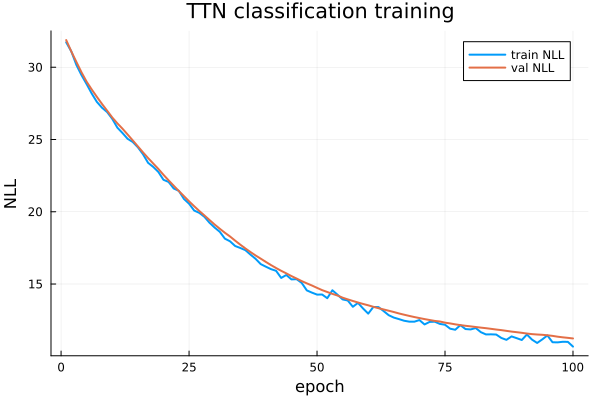

In [6]:
# Training curves
p_nll = plot(title = "TTN classification training", legend = :topright)
plot!(p_nll, ttn_nll_hist, label = "train NLL", lw = 2)
plot!(p_nll, ttn_val_nll,  label = "val NLL",   lw = 2)
xlabel!(p_nll, "epoch"); ylabel!(p_nll, "NLL")
display(p_nll)

## 5. Evaluate Classification

In [7]:
acc_train = classification_accuracy_ttn(ttn, xi_train, n_classes)
println("Train accuracy : ", round(100 * acc_train, digits=1), "%")

xi_test_path = encode_paths(enc, test_paths)
correct_test = 0
for i in 1:N_test
    probs  = class_probabilities_ttn(ttn, xi_test_path[i, :], n_classes)
    y_pred = argmax(probs)
    y_pred == test_labels[i] && (correct_test += 1)
end
acc_test = correct_test / N_test
println("Test  accuracy : ", round(100 * acc_test, digits=1), "%")

Train accuracy : 73.9%
Test  accuracy : 67.8%


In [8]:
println("\nBorn probabilities on first 10 test paths:")
println("  i   True y   p(y=1)   p(y=2)   Pred")
for i in 1:10
    probs  = class_probabilities_ttn(ttn, xi_test_path[i, :], n_classes)
    y_pred = argmax(probs)
    @printf "  %2d    %d      %.4f   %.4f    %d%s\n" i test_labels[i] probs[1] probs[2] y_pred (y_pred == test_labels[i] ? " ✓" : " ✗")
end


Born probabilities on first 10 test paths:
  i   True y   p(y=1)   p(y=2)   Pred
   1    1      0.9351   0.0649    1 ✓
   2    1      0.9035   0.0965    1 ✓
   3    1      0.9579   0.0421    1 ✓
   4    1      0.7549   0.2451    1 ✓
   5    2      0.4315   0.5685    2 ✓
   6    2      0.6086   0.3914    1 ✗
   7    2      0.2073   0.7927    2 ✓
   8    2      0.7832   0.2168    1 ✗
   9    1      0.9941   0.0059    1 ✓
  10    1      0.5767   0.4233    1 ✓


## 6. Logistic Regression Baseline

In [9]:
function logreg_features(paths)
    hcat(paths[:, end], mean(paths, dims=2)[:], std(paths, dims=2)[:])
end

function sigmoid(z); 1 ./ (1 .+ exp.(-z)); end

function logreg_train(X, y; lr=0.1, n_iter=500)
    n, p = size(X)
    w    = zeros(p); b = 0.0
    for _ in 1:n_iter
        logits = X * w .+ b
        phat   = sigmoid(logits)
        err    = phat .- (y .== 1)
        w     -= lr / n .* (X' * err)
        b     -= lr / n .* sum(err)
    end
    return w, b
end

X_train = logreg_features(train_paths)
X_test  = logreg_features(test_paths)

w, b    = logreg_train(X_train, train_labels)

function logreg_acc(X, y, w, b)
    preds = (sigmoid(X * w .+ b) .> 0.5) .+ 1
    mean(preds .== y)
end

lr_train = logreg_acc(X_train, train_labels, w, b)
lr_test  = logreg_acc(X_test,  test_labels,  w, b)

println("Logistic regression:")
println("  Train accuracy: ", round(100 * lr_train, digits=1), "%")
println("  Test  accuracy: ", round(100 * lr_test,  digits=1), "%")

println("\nTTN Born machine:")
println("  Train accuracy: ", round(100 * acc_train, digits=1), "%")
println("  Test  accuracy: ", round(100 * acc_test,  digits=1), "%")

Logistic regression:
  Train accuracy: 28.0%
  Test  accuracy: 25.2%

TTN Born machine:
  Train accuracy: 73.9%
  Test  accuracy: 67.8%


## 7. Discussion

The joint Born machine `p(ξ, y)` is trained entirely via NLL on the joint
sequence `(ξ_1, …, ξ_M, y)` — no special classification objective.
Classification at inference time enumerates `|Ψ(ξ, c)|²` over `c = 1, …, C`.

Compare these numbers to `classification.ipynb` (MPS chain with the same data
and hyperparameters). The tree topology does not follow time order, so TTN
may need more epochs or bond dimension to match MPS accuracy on this task.